In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
print(sklearn.__version__)

1.8.0


# Downloading dataset

In [8]:
from pathlib import Path
import pandas as pd
import kagglehub

dataset_name = "algozee/teenager-menthal-healy"

download_path = kagglehub.dataset_download(dataset_name)
csv_file = list(Path(download_path).glob("*.csv"))[0]
data = pd.read_csv(csv_file)

In [9]:
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [54]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [47]:
data["daily_social_media_hours"].value_counts(normalize=True)

daily_social_media_hours
3.5    0.023333
4.0    0.021667
3.8    0.020833
7.4    0.020000
7.2    0.020000
         ...   
3.7    0.009167
1.9    0.008333
6.7    0.008333
4.9    0.006667
1.0    0.003333
Name: proportion, Length: 71, dtype: float64

In [11]:
import matplotlib.pyplot as plt 

IMAGES_PATH = Path() / "images" / "social_media_impact"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

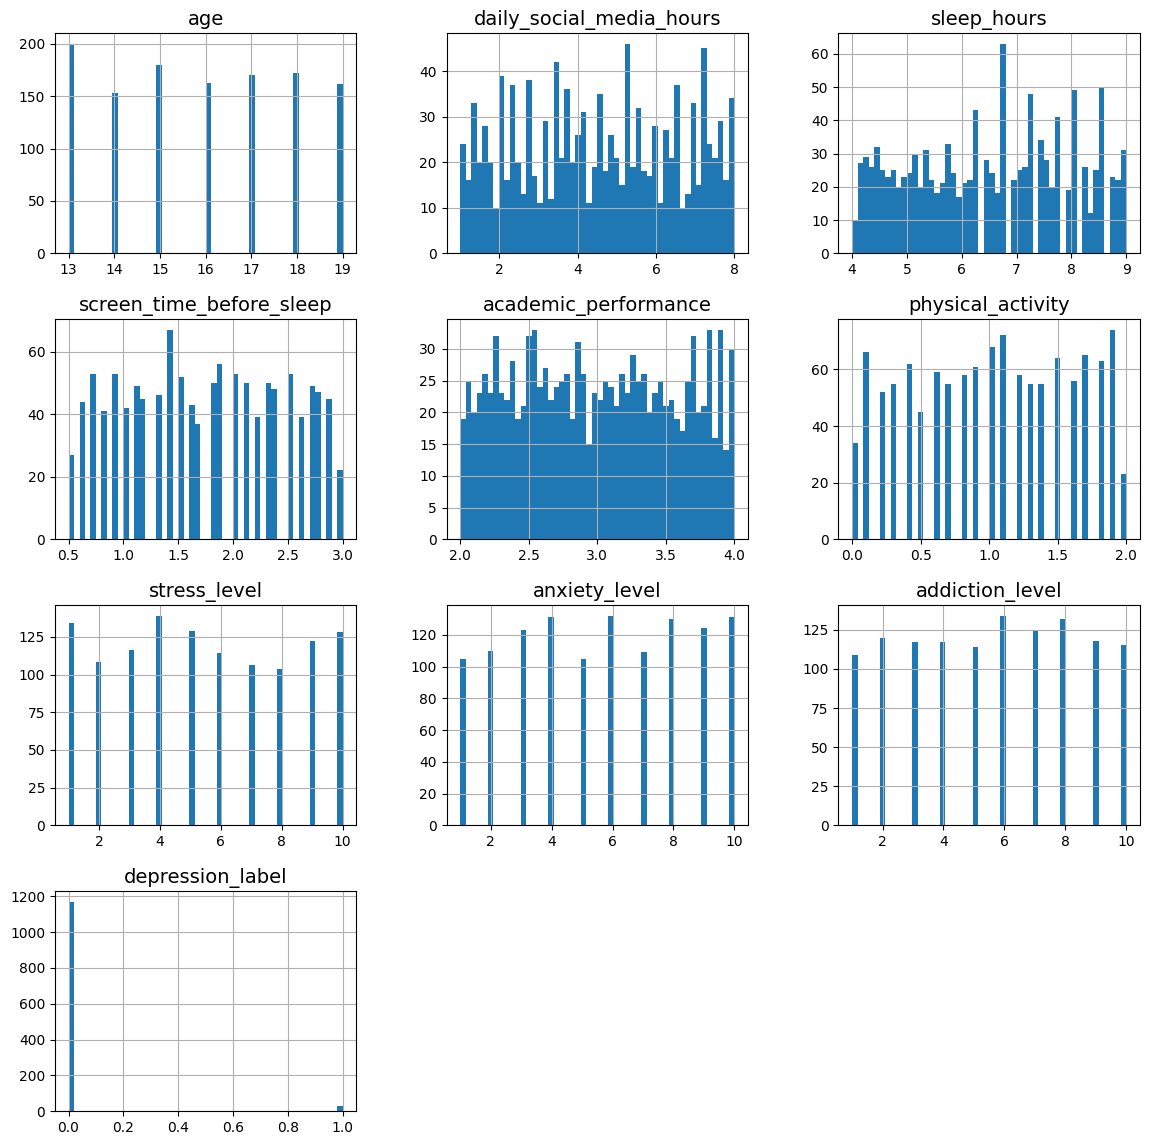

In [17]:
plt.rc("font", size=10)
plt.rc("axes", labelsize=10, titlesize=14)
plt.rc("legend", fontsize=10)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

data.hist(bins=50, figsize=(14, 14))
# save_fig("social media data")
plt.show()

In [19]:
data["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [56]:
import numpy as np

data["usage_cat"] = pd.cut(data["daily_social_media_hours"],
                       bins=[0., 2.0, 4.0, 6.0, np.inf],
                           labels=[1, 2, 3, 4])
data["usage_cat"].value_counts()

usage_cat
2    356
3    336
4    336
1    172
Name: count, dtype: int64

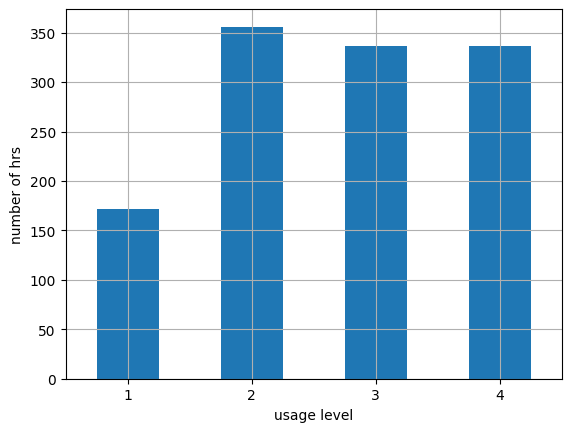

In [72]:
data["usage_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("usage level")
plt.ylabel("number of hrs")
plt.show()

In [77]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    data, test_size=0.2, stratify=data["usage_cat"], random_state=42)

[      age  gender  daily_social_media_hours platform_usage  sleep_hours  \
 491    18  female                       5.7         TikTok          6.2   
 225    19    male                       2.3         TikTok          6.5   
 454    18  female                       4.2      Instagram          5.4   
 39     17  female                       6.3      Instagram          4.0   
 300    13    male                       7.8      Instagram          5.0   
 ...   ...     ...                       ...            ...          ...   
 914    17    male                       4.8         TikTok          6.0   
 428    16  female                       7.8           Both          7.4   
 680    17  female                       6.2           Both          6.1   
 188    16  female                       4.2           Both          7.3   
 1112   14    male                       6.4      Instagram          4.3   
 
       screen_time_before_sleep  academic_performance  physical_activity  \
 491      

In [82]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("usage_cat", axis=1, inplace=True)

In [84]:
addiction = strat_train_set.copy()
addiction.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
491,18,female,5.7,TikTok,6.2,0.5,3.98,1.7,medium,7,6,3,0
225,19,male,2.3,TikTok,6.5,3.0,3.50,0.1,high,9,10,8,0
454,18,female,4.2,Instagram,5.4,1.1,2.31,0.3,low,4,9,1,0
39,17,female,6.3,Instagram,4.0,1.0,2.43,1.2,high,1,10,9,0
300,13,male,7.8,Instagram,5.0,1.8,3.57,1.5,medium,8,10,3,1


In [87]:
corr = addiction.corr(numeric_only=True)
corr["addiction_level"].sort_values(ascending=False)

addiction_level             1.000000
age                         0.043467
physical_activity           0.034554
screen_time_before_sleep    0.030554
academic_performance        0.027871
anxiety_level               0.010029
depression_label            0.000378
stress_level               -0.003886
daily_social_media_hours   -0.044534
sleep_hours                -0.063349
Name: addiction_level, dtype: float64

/var/folders/8m/8bf6sr_d1qqgbfsy0dqhs6640000gn/T/ipykernel_40975/3179415870.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=addiction,


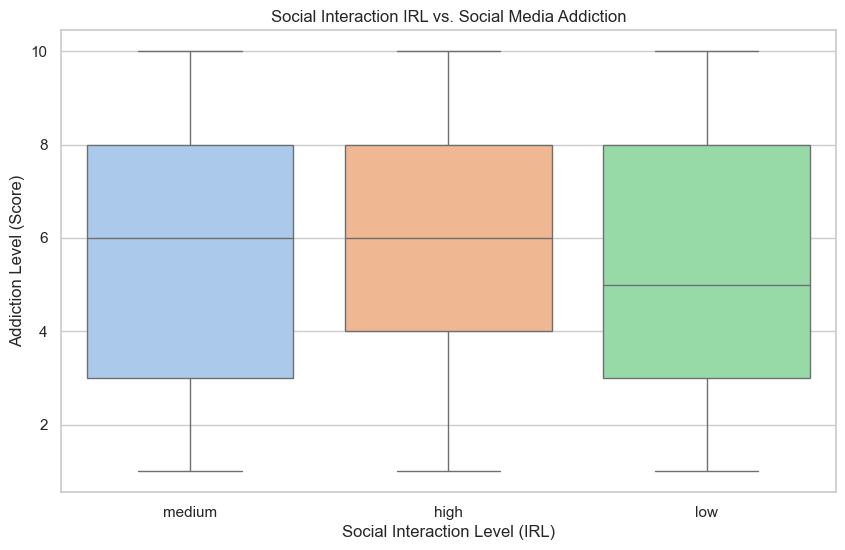

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(data=addiction, 
            x="social_interaction_level", 
            y="addiction_level", 
            palette="pastel")

plt.title("Social Interaction IRL vs. Social Media Addiction")
plt.xlabel("Social Interaction Level (IRL)")
plt.ylabel("Addiction Level (Score)")
plt.show()